# Defect Detection - Exploration
Notebook for data exploration and model experiments.

In [21]:
import xml.etree.ElementTree as ET
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [22]:
def load_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text
        bbox = obj.find("bndbox")
        objects.append({
            "name": name,
            "xmin": int(bbox.find("xmin").text),
            "ymin": int(bbox.find("ymin").text),
            "xmax": int(bbox.find("xmax").text),
            "ymax": int(bbox.find("ymax").text),
        })
    return objects


def show_image_with_boxes(image_path, xml_path):
    img = Image.open(image_path)
    objects = load_annotation(xml_path)

    fig, ax = plt.subplots(1)
    ax.imshow(img, cmap="gray")

    for obj in objects:
        x, y = obj["xmin"], obj["ymin"]
        w, h = obj["xmax"] - obj["xmin"], obj["ymax"] - obj["ymin"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 5, obj["name"], color="red", fontsize=8)

    ax.axis("off")
    plt.title(Path(image_path).name)
    plt.show()

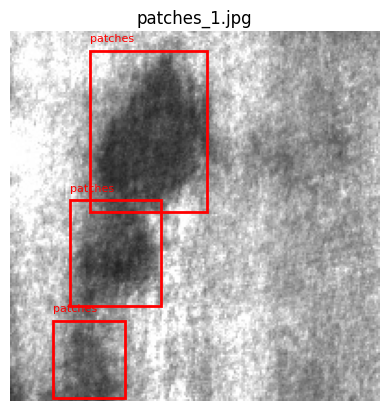

In [24]:
IMAGES_DIR = Path("../examples/images")
ANNOTATIONS_DIR = Path("../examples/annotations")

image_path = IMAGES_DIR / "patches_1.jpg"
xml_path = ANNOTATIONS_DIR / "patches_1.xml"

show_image_with_boxes(image_path, xml_path)